In [ ]:
#no site de dados abertos só daria para ir um ano de cada vez

In [1]:
import requests
import os
import json
import time
from dotenv import load_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt

In [1]:
load_dotenv()
API_KEY = os.environ["API_KEY"]

url = "https://api.portaldatransparencia.gov.br/api-de-dados/cartoes"
headers = {"chave-api-dados": API_KEY}

ARQUIVO_PROGRESSO = "dados_cpcc_2021_2026_progresso.json"

# gera os blocos de 12 meses, de 07/2021 até 06/2026
def gerar_blocos(mes_ini, ano_ini, mes_fim, ano_fim):
    blocos = []
    ano, mes = ano_ini, mes_ini
    while (ano, mes) <= (ano_fim, mes_fim):
        fim_mes, fim_ano = mes + 11, ano
        if fim_mes > 12:
            fim_mes -= 12
            fim_ano += 1
        if (fim_ano, fim_mes) > (ano_fim, mes_fim):
            fim_ano, fim_mes = ano_fim, mes_fim
        blocos.append((f"{mes:02d}/{ano}", f"{fim_mes:02d}/{fim_ano}"))
        mes, ano = fim_mes + 1, fim_ano
        if mes > 12:
            mes, ano = 1, ano + 1
    return blocos

blocos = gerar_blocos(7, 2021, 6, 2026)
print(blocos)

def carregar_progresso():
    if os.path.exists(ARQUIVO_PROGRESSO):
        with open(ARQUIVO_PROGRESSO, "r", encoding="utf-8") as f:
            dados = json.load(f)
        print(f"Retomando: {len(dados)} registros já salvos.")
        return dados
    return []

def salvar_progresso(dados):
    with open(ARQUIVO_PROGRESSO, "w", encoding="utf-8") as f:
        json.dump(dados, f, ensure_ascii=False)

def bloco_ja_feito(dados, bloco_inicio):
    return any(r.get("_bloco_origem") == bloco_inicio for r in dados)

def buscar_dados():
    dados_pags = carregar_progresso()

    for inicio, fim in tqdm(blocos, desc="Blocos de 12 meses", unit="bloco"):
        if bloco_ja_feito(dados_pags, inicio):
            print(f"Bloco {inicio} a {fim} já baixado, pulando.")
            continue

        params = {
            "mesExtratoInicio": inicio,
            "mesExtratoFim": fim,
            "tipoCartao": 2,
            "pagina": 1
        }

        while True:
            try:
                response = requests.get(url, headers=headers, params=params)
                response.raise_for_status()
                dados_json = response.json()

                if not dados_json:
                    break

                for registro in dados_json:
                    registro["_bloco_origem"] = inicio
                    registro["_pagina_origem"] = params["pagina"]

                dados_pags.extend(dados_json)
                salvar_progresso(dados_pags)

                print(f"Bloco {inicio}-{fim}, página {params['pagina']}: {len(dados_pags)} registros no total")

                params["pagina"] += 1
                time.sleep(1.2)

            except requests.exceptions.RequestException as e:
                print(f"Erro no bloco {inicio}-{fim}, página {params['pagina']}: {e}")
                print("Progresso salvo até aqui. Rode a célula de novo pra retomar.")
                return dados_pags

    return dados_pags

dados_pags = buscar_dados()

[('07/2021', '06/2022'), ('07/2022', '06/2023'), ('07/2023', '06/2024'), ('07/2024', '06/2025'), ('07/2025', '06/2026')]


Blocos de 12 meses:   0%|          | 0/5 [00:00<?, ?bloco/s]

Bloco 07/2021-06/2022, página 1: 15 registros no total
Bloco 07/2021-06/2022, página 2: 28 registros no total


Blocos de 12 meses:  20%|██        | 1/5 [00:04<00:16,  4.16s/bloco]

Bloco 07/2022-06/2023, página 1: 43 registros no total
Bloco 07/2022-06/2023, página 2: 45 registros no total


...

Blocos de 12 meses:  60%|██████    | 3/5 [00:11<00:07,  3.70s/bloco]

Bloco 07/2024-06/2025, página 1: 84 registros no total


Blocos de 12 meses:  80%|████████  | 4/5 [00:13<00:02,  2.97s/bloco]

Bloco 07/2025-06/2026, página 1: 99 registros no total
Bloco 07/2025-06/2026, página 2: 114 registros no total
Bloco 07/2025-06/2026, página 3: 129 registros no total
Bloco 07/2025-06/2026, página 4: 138 registros no total


Blocos de 12 meses: 100%|██████████| 5/5 [00:19<00:00,  3.95s/bloco]


In [2]:
import pandas as pd

df_api = pd.read_json("dados_cpcc_2021_2026_progresso.json")

df_api.head()

,id,mesExtrato,dataTransacao,valorTransacao,tipoCartao,estabelecimento,unidadeGestora,portador,_bloco_origem,_pagina_origem
0,488182911,05/2022,02/04/2022,"745,00","{'id': 2, 'codigo': '2', 'descricao': 'Cartão ...","{'id': 8119578, 'cpfFormatado': '', 'cnpjForma...","{'codigo': '158283', 'nome': 'IFMA/CAMPUS BURI...","{'cpfFormatado': '', 'nis': '', 'nome': 'NAO S...",07/2021,1
1,491826110,05/2022,06/04/2022,"420,00","{'id': 2, 'codigo': '2', 'descricao': 'Cartão ...","{'id': -1, 'cpfFormatado': '', 'cnpjFormatado'...","{'codigo': '158283', 'nome': 'IFMA/CAMPUS BURI...","{'cpfFormatado': '', 'nis': '', 'nome': 'NAO S...",07/2021,1
2,495555859,05/2022,05/04/2022,"145,75","{'id': 2, 'codigo': '2', 'descricao': 'Cartão ...","{'id': 6819806, 'cpfFormatado': '', 'cnpjForma...","{'codigo': '158283', 'nome': 'IFMA/CAMPUS BURI...","{'cpfFormatado': '', 'nis': '', 'nome': 'NAO S...",07/2021,1
3,495555923,05/2022,05/04/2022,"57,63","{'id': 2, 'codigo': '2', 'descricao': 'Cartão ...","{'id': 9419797, 'cpfFormatado': '', 'cnpjForma...","{'codigo': '158283', 'nome': 'IFMA/CAMPUS BURI...","{'cpfFormatado': '', 'nis': '', 'nome': 'NAO S...",07/2021,1
4,500048984,05/2022,12/04/2022,"415,98","{'id': 2, 'codigo': '2', 'descricao': 'Cartão ...","{'id': 6019904, 'cpfFormatado': '', 'cnpjForma...","{'codigo': '810005', 'nome': 'COORDENACAO-GERA...","{'cpfFormatado': '', 'nis': '', 'nome': 'NAO S...",07/2021,1


In [3]:
#já tá salvo não precisa rodar essa de novo.
#salvei como csv como um backup, mas estou analisando o arquvio em json
#já que as colunas são tem dicionários dentro.
df.to_csv(
    "dados_cpcc_cpcc_2021_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
#tentei 10 anos > não deu certo.

In [ ]:
#comparar csv do gov com api 
#de 1 ano > pq csv só vai ano por ano. 
#separar um ano do meu csv 
#baixar e abrir um ano gov csv

In [3]:
#sempre lembrar de colocar as coisas de gov br 
#enconding e sep (pq ele sempre separa por ponto e vírgula)
df_gov = pd.read_csv('cartoes.csv', sep=';', encoding='utf-8')
df_gov.head()

,TIPO DE CARTÃO,Órgão Superior,Órgão/Entidade Vinculada,CPF PORTADOR,NOME PORTADOR,VALOR GASTO NO PERIODO (R$),Unnamed: 6
0,Cartão de Pagamento de Compras Centralizadas -...,52000 - Ministério da Defesa,52904 - Fundo do Exército,Não se aplica,NAO SE APLICA,"1,33",NaN
1,Cartão de Pagamento de Compras Centralizadas -...,26000 - Ministério da Educação,"26438 - Instituto Federal de Educação, Ciência...",Não se aplica,NAO SE APLICA,"1,62",NaN
2,Cartão de Pagamento de Compras Centralizadas -...,52000 - Ministério da Defesa,52121 - Comando do Exército,Não se aplica,NAO SE APLICA,"6,00",NaN
3,Cartão de Pagamento de Compras Centralizadas -...,26000 - Ministério da Educação,"26426 - Instituto Federal de Educação, Ciência...",Não se aplica,NAO SE APLICA,"13,90",NaN
4,Cartão de Pagamento de Compras Centralizadas -...,26000 - Ministério da Educação,"26426 - Instituto Federal de Educação, Ciência...",Não se aplica,NAO SE APLICA,"20,00",NaN


In [11]:
#comparar colunas de cada um para mostrar quais infos a api tem que o csv do gov nao dá
df_gov.columns

Index(['TIPO DE CARTÃO', 'Órgão Superior', 'Órgão/Entidade Vinculada',
       'CPF PORTADOR', 'NOME PORTADOR', 'VALOR GASTO NO PERIODO (R$)',
       'Unnamed: 6'],
      dtype='str')

In [12]:
df_api.columns

Index(['id', 'mesExtrato', 'dataTransacao', 'valorTransacao', 'tipoCartao',
       'estabelecimento', 'unidadeGestora', 'portador', '_bloco_origem',
       '_pagina_origem'],
      dtype='str')

In [ ]:
#'TIPO DE CARTÃO' = 'tipoCartao' 
# 'Órgão Superior'
#'Órgão/Entidade Vinculada' = 'unidadeGestora' > da api > tem codigo, nome, orgao vinculado
#'NOME PORTADOR' =  'portador'
#'VALOR GASTO NO PERIODO (R$)' = 'valorTransacao'
# ---  = 'estabelecimento' (só na api)
# ---- = 'dataTransacao' > específica (só na api)

In [ ]:
#conclusão: na api tem info específica da data de cada transação 
#pega mais de um ano de uma vez
#e mostra qual transação foi para qual estabelecimento > no gov, não relaciona diretamente.

In [14]:
df_api['unidadeGestora'][0]

{'codigo': '158283',
 'nome': 'IFMA/CAMPUS BURITICUPU',
 'descricaoPoder': 'EXECUTIVO',
 'orgaoVinculado': {'codigoSIAFI': '26408',
  'cnpj': '10735145000194',
  'sigla': 'IFMA',
  'nome': 'Instituto Federal de Educação, Ciência e Tecnologia do Maranhão'},
 'orgaoMaximo': {'codigo': '26000',
  'sigla': 'MEC',
  'nome': 'Ministério da Educação'}}

In [ ]:
#análise dados dos últimos 5 anos da api

In [15]:
df_api.columns

Index(['id', 'mesExtrato', 'dataTransacao', 'valorTransacao', 'tipoCartao',
       'estabelecimento', 'unidadeGestora', 'portador', '_bloco_origem',
       '_pagina_origem'],
      dtype='str')

In [3]:
#ver se tipo de cartão é sempre o mesmo, se não tem nenhum nulo

df_api['tipoCartao'].value_counts()

#só tem o CPCC, então, vale a pena tirar essa coluna.

tipoCartao
{'id': 2, 'codigo': '2', 'descricao': 'Cartão de Pagamento de Compras Centralizadas - CPCC'}    138
Name: count, dtype: int64

In [ ]:
#ver se não tem nenhum valor nulo no tipodecartão ou paginadeorigem 

In [25]:
df_api['tipoCartao'].isna().sum()

np.int64(0)

In [26]:
df_api['_pagina_origem'].isna().sum()

np.int64(0)

In [3]:
#limpar colunas 
#tirar página de origem e tipo de cartão
df_api_clean = df_api.drop(columns=['_pagina_origem', 'tipoCartao'])
df_api_clean.columns

Index(['id', 'mesExtrato', 'dataTransacao', 'valorTransacao',
       'estabelecimento', 'unidadeGestora', 'portador', '_bloco_origem'],
      dtype='str')

In [6]:
#138 registros entre 07/2021 e 06/2026 
#é bem pouco comparado com os outros cartões.
#pq será?
#quem ainda usa esse cartão?
#para que?
df_api_clean.shape

(138, 8)

In [4]:
#passar colunas com datas para datetime
df_api_clean['dataTransacao'] = pd.to_datetime(df_api_clean['dataTransacao'], format='%d/%m/%Y')
df_api_clean['dataTransacao'].value_counts(ascending=True)

dataTransacao
2022-04-02    1
2022-04-06    1
2022-04-12    1
2022-04-20    1
2022-05-05    1
             ..
2023-11-28    4
2024-09-04    4
2026-03-07    4
2025-12-04    4
2026-04-04    5
Name: count, Length: 89, dtype: int64

In [5]:
df_api_clean['mesExtrato'] = pd.to_datetime(df_api_clean['mesExtrato'], format='%m/%Y')
df_api_clean['mesExtrato']

0     2022-05-01
1     2022-05-01
2     2022-05-01
3     2022-05-01
4     2022-05-01
         ...    
133   2026-05-01
134   2026-04-01
135   2026-04-01
136   2026-04-01
137   2026-04-01
Name: mesExtrato, Length: 138, dtype: datetime64[us]

In [9]:
#ver se uso data de extrado ou transação > deu bem parecido, então vou usar transação. 
print("Meses únicos em mesExtrato:", df_api_clean['mesExtrato'].nunique())
print("Meses únicos em dataTransacao:", df_api_clean['dataTransacao'].dt.to_period('M').nunique())

Meses únicos em mesExtrato: 33
Meses únicos em dataTransacao: 32


In [ ]:
#passar colunas com valores para numérico
#https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html (explicação)
#se der certo, o tipo novo é float64 or int64 
#float são números com vírgula
#https://www.youtube.com/watch?v=MU2KsvDZvIU > explicação do to_numeric

In [6]:
df_api_clean['valorTransacao'] = pd.to_numeric(
    df_api_clean['valorTransacao']
        .astype(str) #para mudar o tipo
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False),
    errors='coerce' #é para, se tiver coisas q ñ números, registrar como Nan e não dar erro. 
)

df_api_clean['valorTransacao'].dtype

dtype('float64')

In [8]:
df_api_clean['valorTransacao'].isna().sum()

np.int64(0)

In [9]:
df_api_clean['valorTransacao']

0       745.00
1       420.00
2       145.75
3        57.63
4       415.98
        ...   
133      68.97
134    1770.00
135     404.91
136    2500.00
137    1194.40
Name: valorTransacao, Length: 138, dtype: float64

In [10]:
#describe() mostra geralzão
df_api_clean['valorTransacao'].describe()

count     138.000000
mean      522.025942
std       601.918113
min         1.330000
25%       126.250000
50%       296.000000
75%       669.500000
max      3400.000000
Name: valorTransacao, dtype: float64

In [ ]:
#json_normalize nas colunas unidadeGestora, estabelecimento e portador
#pra agrupar por órgão e por estabelecimento.
#json normalize > transforms semi-structured JSON data, such as nested dictionaries or lists, into a flat table. 

In [11]:
df_api_clean.head()

,id,mesExtrato,dataTransacao,valorTransacao,estabelecimento,unidadeGestora,portador,_bloco_origem
0,488182911,2022-05-01,2022-04-02,745.00,"{'id': 8119578, 'cpfFormatado': '', 'cnpjForma...","{'codigo': '158283', 'nome': 'IFMA/CAMPUS BURI...","{'cpfFormatado': '', 'nis': '', 'nome': 'NAO S...",07/2021
1,491826110,2022-05-01,2022-04-06,420.00,"{'id': -1, 'cpfFormatado': '', 'cnpjFormatado'...","{'codigo': '158283', 'nome': 'IFMA/CAMPUS BURI...","{'cpfFormatado': '', 'nis': '', 'nome': 'NAO S...",07/2021
2,495555859,2022-05-01,2022-04-05,145.75,"{'id': 6819806, 'cpfFormatado': '', 'cnpjForma...","{'codigo': '158283', 'nome': 'IFMA/CAMPUS BURI...","{'cpfFormatado': '', 'nis': '', 'nome': 'NAO S...",07/2021
3,495555923,2022-05-01,2022-04-05,57.63,"{'id': 9419797, 'cpfFormatado': '', 'cnpjForma...","{'codigo': '158283', 'nome': 'IFMA/CAMPUS BURI...","{'cpfFormatado': '', 'nis': '', 'nome': 'NAO S...",07/2021
4,500048984,2022-05-01,2022-04-12,415.98,"{'id': 6019904, 'cpfFormatado': '', 'cnpjForma...","{'codigo': '810005', 'nome': 'COORDENACAO-GERA...","{'cpfFormatado': '', 'nis': '', 'nome': 'NAO S...",07/2021


In [ ]:
#as colunas: 
#estabelecimento	
#unidadeGestora	
#portador
#tem dicionários dentro

In [11]:
df_api_clean['estabelecimento'][0]

{'id': 8119578,
 'cpfFormatado': '',
 'cnpjFormatado': '07.231.952/0001-65',
 'numeroInscricaoSocial': '',
 'nome': 'AGUAS CLARAS PRODUTOS E EQUIPAMENTOS PARA LAZER LTDA',
 'razaoSocialReceita': 'AGUAS CLARAS PRODUTOS E EQUIPAMENTOS PARA LAZER LTDA',
 'nomeFantasiaReceita': 'AGUAS CLARAS PISCINAS',
 'tipo': 'Entidades Empresariais Privadas'}

In [14]:
df_api_clean['unidadeGestora'][0]
#dá pra ver que são dicionários dentro de dicionários > nested

{'codigo': '158283',
 'nome': 'IFMA/CAMPUS BURITICUPU',
 'descricaoPoder': 'EXECUTIVO',
 'orgaoVinculado': {'codigoSIAFI': '26408',
  'cnpj': '10735145000194',
  'sigla': 'IFMA',
  'nome': 'Instituto Federal de Educação, Ciência e Tecnologia do Maranhão'},
 'orgaoMaximo': {'codigo': '26000',
  'sigla': 'MEC',
  'nome': 'Ministério da Educação'}}

In [ ]:
#conferir se em alguma das três colunas nested, têm diiconários com listas.
#isinstance > (é basicamente perguntar para o python se é o elemnto é está num formato específico.
#se tiver, ele responde True.

In [15]:
def tem_lista_em_algum_nivel(obj):
    if isinstance(obj, list):
        return True
    if isinstance(obj, dict):
        return any(tem_lista_em_algum_nivel(v) for v in obj.values())
    return False

for col in ['unidadeGestora', 'estabelecimento', 'portador']:
    tem_lista = df_api_clean[col].apply(tem_lista_em_algum_nivel).any()
    print(f"{col}: tem lista em algum nível? {tem_lista}")

unidadeGestora: tem lista em algum nível? False
estabelecimento: tem lista em algum nível? False
portador: tem lista em algum nível? False


In [7]:
#desempacotar as colunas de dicionário
#criar colunas separadas para cada item dentro dos nested dicionários

unidade_gestora = pd.json_normalize(df_api_clean['unidadeGestora']) #transforma de normalize json
unidade_gestora.columns = ['unidade_gestora_' + c for c in unidade_gestora.columns] #faz um loop entre os dicionários

estabelecimento = pd.json_normalize(df_api_clean['estabelecimento'])
estabelecimento.columns = ['estabelecimento_' + c for c in estabelecimento.columns]

portador = pd.json_normalize(df_api_clean['portador'])
portador.columns = ['portador_' + c for c in portador.columns]

In [8]:
# juntar tudo num dataframe só

df_final = pd.concat(
 [df_api_clean.reset_index(drop=True),unidade_gestora, estabelecimento, portador],
 axis=1
)
df_final.columns

Index(['id', 'mesExtrato', 'dataTransacao', 'valorTransacao',
       'estabelecimento', 'unidadeGestora', 'portador', '_bloco_origem',
       'unidade_gestora_codigo', 'unidade_gestora_nome',
       'unidade_gestora_descricaoPoder',
       'unidade_gestora_orgaoVinculado.codigoSIAFI',
       'unidade_gestora_orgaoVinculado.cnpj',
       'unidade_gestora_orgaoVinculado.sigla',
       'unidade_gestora_orgaoVinculado.nome',
       'unidade_gestora_orgaoMaximo.codigo',
       'unidade_gestora_orgaoMaximo.sigla', 'unidade_gestora_orgaoMaximo.nome',
       'estabelecimento_id', 'estabelecimento_cpfFormatado',
       'estabelecimento_cnpjFormatado',
       'estabelecimento_numeroInscricaoSocial', 'estabelecimento_nome',
       'estabelecimento_razaoSocialReceita',
       'estabelecimento_nomeFantasiaReceita', 'estabelecimento_tipo',
       'portador_cpfFormatado', 'portador_nis', 'portador_nome'],
      dtype='str')

In [9]:
# tirar as colunas antigas de dicionário, já não precisa mais delas
df_final = df_final.drop(columns=['unidadeGestora', 'estabelecimento', 'portador', '_bloco_origem'], errors='ignore')
df_final.columns

Index(['id', 'mesExtrato', 'dataTransacao', 'valorTransacao',
       'unidade_gestora_codigo', 'unidade_gestora_nome',
       'unidade_gestora_descricaoPoder',
       'unidade_gestora_orgaoVinculado.codigoSIAFI',
       'unidade_gestora_orgaoVinculado.cnpj',
       'unidade_gestora_orgaoVinculado.sigla',
       'unidade_gestora_orgaoVinculado.nome',
       'unidade_gestora_orgaoMaximo.codigo',
       'unidade_gestora_orgaoMaximo.sigla', 'unidade_gestora_orgaoMaximo.nome',
       'estabelecimento_id', 'estabelecimento_cpfFormatado',
       'estabelecimento_cnpjFormatado',
       'estabelecimento_numeroInscricaoSocial', 'estabelecimento_nome',
       'estabelecimento_razaoSocialReceita',
       'estabelecimento_nomeFantasiaReceita', 'estabelecimento_tipo',
       'portador_cpfFormatado', 'portador_nis', 'portador_nome'],
      dtype='str')

In [15]:
df_final.head()

,id,mesExtrato,dataTransacao,valorTransacao,unidade_gestora_codigo,unidade_gestora_nome,unidade_gestora_descricaoPoder,unidade_gestora_orgaoVinculado.codigoSIAFI,unidade_gestora_orgaoVinculado.cnpj,unidade_gestora_orgaoVinculado.sigla,...,estabelecimento_cpfFormatado,estabelecimento_cnpjFormatado,estabelecimento_numeroInscricaoSocial,estabelecimento_nome,estabelecimento_razaoSocialReceita,estabelecimento_nomeFantasiaReceita,estabelecimento_tipo,portador_cpfFormatado,portador_nis,portador_nome
0,488182911,2022-05-01,2022-04-02,745.00,158283,IFMA/CAMPUS BURITICUPU,EXECUTIVO,26408,10735145000194,IFMA,...,,07.231.952/0001-65,,AGUAS CLARAS PRODUTOS E EQUIPAMENTOS PARA LAZE...,AGUAS CLARAS PRODUTOS E EQUIPAMENTOS PARA LAZE...,AGUAS CLARAS PISCINAS,Entidades Empresariais Privadas,,,NAO SE APLICA
1,491826110,2022-05-01,2022-04-06,420.00,158283,IFMA/CAMPUS BURITICUPU,EXECUTIVO,26408,10735145000194,IFMA,...,,,,SEM INFORMACAO,SEM INFORMACAO,SEM INFORMACAO,Sem Informação,,,NAO SE APLICA
2,495555859,2022-05-01,2022-04-05,145.75,158283,IFMA/CAMPUS BURITICUPU,EXECUTIVO,26408,10735145000194,IFMA,...,,12.114.724/0001-45,,A J BARBOSA LTDA,A J BARBOSA LTDA,CENTRO ELETRICO,Entidades Empresariais Privadas,,,NAO SE APLICA
3,495555923,2022-05-01,2022-04-05,57.63,158283,IFMA/CAMPUS BURITICUPU,EXECUTIVO,26408,10735145000194,IFMA,...,,03.867.404/0001-75,,ORIZA - MATERIAIS DE CONSTRUCOES LTDA,ORIZA - MATERIAIS DE CONSTRUCOES LTDA,,Entidades Empresariais Privadas,,,NAO SE APLICA
4,500048984,2022-05-01,2022-04-12,415.98,810005,COORDENACAO-GERAL DE LOGISTICA - MDHC,EXECUTIVO,81000,27136980000100,MDHC,...,,07.575.651/0001-59,,GOL LINHAS AEREAS S.A.,GOL LINHAS AEREAS S.A.,,Entidades Empresariais Privadas,,,NAO SE APLICA


In [ ]:
#limpar colunas excessivas. 
#por ex. portador é sempre 'não se aplica', certo?
#então as colunas
#portador_cpfFormatado
#portador_nis
#estão vazias.

In [16]:
#quantas delas estão vazias com '' > todas.
(df_final[['portador_cpfFormatado', 'portador_nis']] == '').sum()

portador_cpfFormatado    138
portador_nis             138
dtype: int64

In [17]:
#tds da coluna portador_nome estão com não se aplica!
(df_final['portador_nome'] == 'NAO SE APLICA').sum()

np.int64(138)

In [15]:
df_final = df_final.drop(columns=['portador_cpfFormatado', 'portador_nis','portador_nome'])
df_final.columns

Index(['id', 'mesExtrato', 'dataTransacao', 'valorTransacao',
       'unidade_gestora_codigo', 'unidade_gestora_nome',
       'unidade_gestora_descricaoPoder',
       'unidade_gestora_orgaoVinculado.codigoSIAFI',
       'unidade_gestora_orgaoVinculado.cnpj',
       'unidade_gestora_orgaoVinculado.sigla',
       'unidade_gestora_orgaoVinculado.nome',
       'unidade_gestora_orgaoMaximo.codigo',
       'unidade_gestora_orgaoMaximo.sigla', 'unidade_gestora_orgaoMaximo.nome',
       'estabelecimento_id', 'estabelecimento_cpfFormatado',
       'estabelecimento_cnpjFormatado',
       'estabelecimento_numeroInscricaoSocial', 'estabelecimento_nome',
       'estabelecimento_razaoSocialReceita',
       'estabelecimento_nomeFantasiaReceita', 'estabelecimento_tipo'],
      dtype='str')

In [19]:
df_final.head()
#como nem todos tem nome fantasia estab_nomeFantasiaReceita > vou tirar essa e deixar só razão social
#estab_numeroInscricaoSocial está vazio? ''
#vou tirar o mesExtrato e deixar só dataTransicao
#vou tirar o unidade_gestora_orgaoMaximo.sigla e deixar só o unidade_gestora_orgaoMaximo

,id,mesExtrato,dataTransacao,valorTransacao,unidade_gestora_codigo,unidade_gestora_nome,unidade_gestora_descricaoPoder,unidade_gestora_orgaoVinculado.codigoSIAFI,unidade_gestora_orgaoVinculado.cnpj,unidade_gestora_orgaoVinculado.sigla,...,unidade_gestora_orgaoMaximo.sigla,unidade_gestora_orgaoMaximo.nome,estabelecimento_id,estabelecimento_cpfFormatado,estabelecimento_cnpjFormatado,estabelecimento_numeroInscricaoSocial,estabelecimento_nome,estabelecimento_razaoSocialReceita,estabelecimento_nomeFantasiaReceita,estabelecimento_tipo
0,488182911,2022-05-01,2022-04-02,745.00,158283,IFMA/CAMPUS BURITICUPU,EXECUTIVO,26408,10735145000194,IFMA,...,MEC,Ministério da Educação,8119578,,07.231.952/0001-65,,AGUAS CLARAS PRODUTOS E EQUIPAMENTOS PARA LAZE...,AGUAS CLARAS PRODUTOS E EQUIPAMENTOS PARA LAZE...,AGUAS CLARAS PISCINAS,Entidades Empresariais Privadas
1,491826110,2022-05-01,2022-04-06,420.00,158283,IFMA/CAMPUS BURITICUPU,EXECUTIVO,26408,10735145000194,IFMA,...,MEC,Ministério da Educação,-1,,,,SEM INFORMACAO,SEM INFORMACAO,SEM INFORMACAO,Sem Informação
2,495555859,2022-05-01,2022-04-05,145.75,158283,IFMA/CAMPUS BURITICUPU,EXECUTIVO,26408,10735145000194,IFMA,...,MEC,Ministério da Educação,6819806,,12.114.724/0001-45,,A J BARBOSA LTDA,A J BARBOSA LTDA,CENTRO ELETRICO,Entidades Empresariais Privadas
3,495555923,2022-05-01,2022-04-05,57.63,158283,IFMA/CAMPUS BURITICUPU,EXECUTIVO,26408,10735145000194,IFMA,...,MEC,Ministério da Educação,9419797,,03.867.404/0001-75,,ORIZA - MATERIAIS DE CONSTRUCOES LTDA,ORIZA - MATERIAIS DE CONSTRUCOES LTDA,,Entidades Empresariais Privadas
4,500048984,2022-05-01,2022-04-12,415.98,810005,COORDENACAO-GERAL DE LOGISTICA - MDHC,EXECUTIVO,81000,27136980000100,MDHC,...,MDHC,Ministério dos Direitos Humanos e Cidadania,6019904,,07.575.651/0001-59,,GOL LINHAS AEREAS S.A.,GOL LINHAS AEREAS S.A.,,Entidades Empresariais Privadas


In [10]:
df_final = df_final.drop(columns = ['estab_nomeFantasiaReceita', 'mesExtrato',  'estabelecimento_nomeFantasiaReceita', 'unidade_gestora_orgaoVinculado.codigoSIAFI','unidade_gestora_orgaoMaximo.sigla',  'unidade_gestora_codigo', 'unidade_gestora_orgaoVinculado.sigla', 'estab_nome', 'unidade_gestora_descricaoPoder'], errors='ignore')
df_final.columns

Index(['id', 'dataTransacao', 'valorTransacao', 'unidade_gestora_nome',
       'unidade_gestora_orgaoVinculado.cnpj',
       'unidade_gestora_orgaoVinculado.nome',
       'unidade_gestora_orgaoMaximo.codigo',
       'unidade_gestora_orgaoMaximo.nome', 'estabelecimento_id',
       'estabelecimento_cpfFormatado', 'estabelecimento_cnpjFormatado',
       'estabelecimento_numeroInscricaoSocial', 'estabelecimento_nome',
       'estabelecimento_razaoSocialReceita', 'estabelecimento_tipo',
       'portador_cpfFormatado', 'portador_nis', 'portador_nome'],
      dtype='str')

In [36]:
#unidade_gestora_descricaoPoder > não é sempre executivo? é. 
(df_final['unidade_gestora_descricaoPoder'] == 'EXECUTIVO').sum()

KeyError: 'unidade_gestora_descricaoPoder'

In [22]:
df_final.head()

,id,dataTransacao,valorTransacao,unidade_gestora_nome,unidade_gestora_orgaoVinculado.cnpj,unidade_gestora_orgaoVinculado.nome,unidade_gestora_orgaoMaximo.codigo,unidade_gestora_orgaoMaximo.nome,estabelecimento_id,estabelecimento_cpfFormatado,estabelecimento_cnpjFormatado,estabelecimento_numeroInscricaoSocial,estabelecimento_nome,estabelecimento_razaoSocialReceita,estabelecimento_tipo
0,488182911,2022-04-02,745.00,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,8119578,,07.231.952/0001-65,,AGUAS CLARAS PRODUTOS E EQUIPAMENTOS PARA LAZE...,AGUAS CLARAS PRODUTOS E EQUIPAMENTOS PARA LAZE...,Entidades Empresariais Privadas
1,491826110,2022-04-06,420.00,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,-1,,,,SEM INFORMACAO,SEM INFORMACAO,Sem Informação
2,495555859,2022-04-05,145.75,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,6819806,,12.114.724/0001-45,,A J BARBOSA LTDA,A J BARBOSA LTDA,Entidades Empresariais Privadas
3,495555923,2022-04-05,57.63,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,9419797,,03.867.404/0001-75,,ORIZA - MATERIAIS DE CONSTRUCOES LTDA,ORIZA - MATERIAIS DE CONSTRUCOES LTDA,Entidades Empresariais Privadas
4,500048984,2022-04-12,415.98,COORDENACAO-GERAL DE LOGISTICA - MDHC,27136980000100,Ministério dos Direitos Humanos e Cidadania - ...,81000,Ministério dos Direitos Humanos e Cidadania,6019904,,07.575.651/0001-59,,GOL LINHAS AEREAS S.A.,GOL LINHAS AEREAS S.A.,Entidades Empresariais Privadas


In [23]:
#ver se essa coluna está vazia
#não são todas aparentemente.
(df_final['estab_cpfFormatado'] == '').sum()

KeyError: 'estab_cpfFormatado'

In [24]:
#só algns tem cpf.
df_final['estab_cpfFormatado']

KeyError: 'estab_cpfFormatado'

<Axes: xlabel='dataTransacao', ylabel='valorTransacao'>

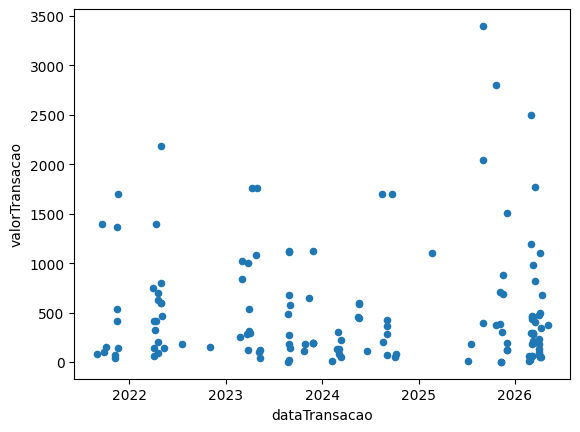

In [27]:
# kind Valid plot kinds: ('line', 'bar', 'barh', 'kde', 'density', 'area', 'hist', 'box', 'pie', 'scatter', 'hexbin')
#valor gasto por tempo
df_final.plot(x='dataTransacao', y='valorTransacao', kind= 'scatter')

<Axes: xlabel='dataTransacao', ylabel='unidade_gestora_orgaoMaximo.nome'>

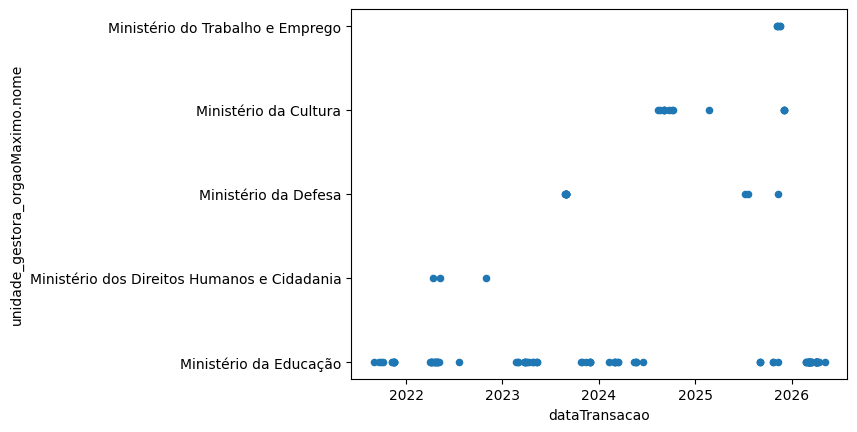

In [28]:
df_final.plot(x='dataTransacao', y='unidade_gestora_orgaoMaximo.nome', kind= 'scatter')

In [ ]:
#quem foram os que gastaram e receberam com mais frequencia?
#quem pagou e quem recebeu os maiores valores?

In [29]:
df_final.columns

Index(['id', 'dataTransacao', 'valorTransacao', 'unidade_gestora_nome',
       'unidade_gestora_orgaoVinculado.cnpj',
       'unidade_gestora_orgaoVinculado.nome',
       'unidade_gestora_orgaoMaximo.codigo',
       'unidade_gestora_orgaoMaximo.nome', 'estabelecimento_id',
       'estabelecimento_cpfFormatado', 'estabelecimento_cnpjFormatado',
       'estabelecimento_numeroInscricaoSocial', 'estabelecimento_nome',
       'estabelecimento_razaoSocialReceita', 'estabelecimento_tipo'],
      dtype='str')

In [19]:
#diminuir/simplificar nome das colunas
#para renomear colunas > rename
df_final = df_final.rename(columns={'unidade_gestora_orgaoMaximo.nome': 'orgao_max_nome', 'unidade_gestora_orgaoMaximo.codigo': 'orgaoMaximo.codigo', 'unidade_gestora_orgaoVinculado.cnpj': 'orgaoVinculado.cnpj',
       'unidade_gestora_orgaoVinculado.nome': 'orgaoVinculado.nome'
})
df_final.columns

Index(['id', 'dataTransacao', 'valorTransacao', 'unidade_gestora_nome',
       'orgaoVinculado.cnpj', 'orgaoVinculado.nome', 'orgaoMaximo.codigo',
       'orgao_max_nome', 'estabelecimento_id', 'estabelecimento_cpfFormatado',
       'estabelecimento_cnpjFormatado',
       'estabelecimento_numeroInscricaoSocial', 'estabelecimento_nome',
       'estabelecimento_razaoSocialReceita', 'estabelecimento_tipo',
       'portador_cpfFormatado', 'portador_nis', 'portador_nome'],
      dtype='str')

In [ ]:
#unidade gestora: entidade exata que fez a compra > ela faz parte de uma algum órgão do governo. 
#unidade_gestora_orgaoVinculado.nome (nível do meio):
#o órgão que ela faz parte > 'unidade_gestora_orgaoMaximo.nome'
#quem recebeu 'estabelecimento_nome','estabelecimento_tipo'

In [ ]:
#quem foram os que gastaram e receberam com mais frequencia?
#quem pagou e quem recebeu os maiores valores?

In [ ]:
#qual órgão gastou mais?

In [21]:
#no groupby sempre deixar valor numérico dentro do parênteses
#o reset index faz virar um df.
orgao_max_gastos_21_26 = df_final.groupby('orgao_max_nome')['valorTransacao'].sum().sort_values(ascending=False).reset_index()
orgao_max_gastos_21_26

,orgao_max_nome,valorTransacao
0,Ministério da Educação,55665.10
1,Ministério da Cultura,7920.29
2,Ministério da Defesa,4794.73
3,Ministério do Trabalho e Emprego,2950.18
4,Ministério dos Direitos Humanos e Cidadania,709.28


In [22]:
#com porcentagem
#define o valor total dos gastos nesse cartao em todo o df 72039.58
valor_total = orgao_max_gastos_21_26['valorTransacao'].sum()
valor_total

np.float64(72039.57999999999)

In [41]:
#cria uma coluna de porcentagem
orgao_max_gastos_21_26['porcentagem'] = (orgao_max_gastos_21_26['valorTransacao'] / valor_total * 100).round(1)
orgao_max_gastos_21_26

,orgao_max_nome,valorTransacao,porcentagem
0,Ministério da Educação,55665.10,77.3
1,Ministério da Cultura,7920.29,11.0
2,Ministério da Defesa,4794.73,6.7
3,Ministério do Trabalho e Emprego,2950.18,4.1
4,Ministério dos Direitos Humanos e Cidadania,709.28,1.0


In [42]:
#salvar como csv para mexer no flourish 
orgao_max_gastos_21_26.to_csv('orgao_gastos_21_26.csv')

<Axes: ylabel='orgao_max_nome'>

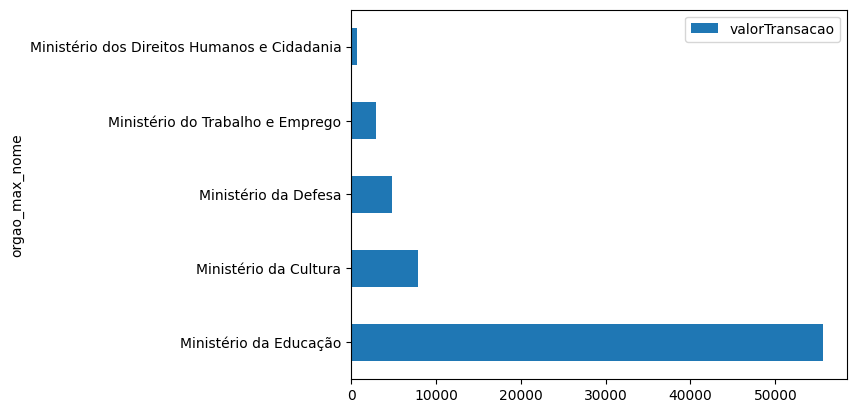

In [44]:
#isso é valor dos gastos e não frequência 
orgao_max_gastos_21_26.plot(x= 'orgao_max_nome', y = 'valorTransacao', kind='barh' )

In [ ]:
#qual foi o maior gasto de todo período?
#esses gastos são de passagem aérea?
#quem foi o recebedor?
#e o pagante

In [35]:
df_final['orgao_max_nome'].unique()

<StringArray>
[                     'Ministério da Educação',
 'Ministério dos Direitos Humanos e Cidadania',
                        'Ministério da Defesa',
                       'Ministério da Cultura',
            'Ministério do Trabalho e Emprego']
Length: 5, dtype: str

In [13]:
#gasto individual.
#foi do IFMA/CAMPUS BURITICUPU para
#foi para uma pessoa física > CLAUDIA MARIA BEZERRA LIMA
top_5_maiores_gastos_individuais = df_final.sort_values('valorTransacao', ascending=False).iloc[0:5]
top_5_maiores_gastos_individuais

,id,dataTransacao,valorTransacao,unidade_gestora_nome,orgaoVinculado.cnpj,orgaoVinculado.nome,orgaoMaximo.codigo,orgao_max_nome,estabelecimento_id,estabelecimento_cpfFormatado,estabelecimento_cnpjFormatado,estabelecimento_numeroInscricaoSocial,estabelecimento_nome,estabelecimento_razaoSocialReceita,estabelecimento_tipo,portador_cpfFormatado,portador_nis,portador_nome
130,552738987,2025-09-04,3400.0,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,608442748,***.481.413-**,,16427007433,CLAUDIA MARIA BEZERRA LIMA,,Pessoa Física,,,NAO SE APLICA
123,536127296,2025-10-21,2800.0,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,608453052,,29.299.282/0001-51,,N CUNHA SANTOS LTDA,N CUNHA SANTOS LTDA,Entidades Empresariais Privadas,,,NAO SE APLICA
136,575143544,2026-03-05,2500.0,INSTITUTO FED DO AP CAMPUS AGRIC PORTO GRANDE,10820882000195,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,360717389,,34.101.761/0001-51,,AGROVET PRODUTOS AGRICOLAS LTDA,AGROVET PRODUTOS AGRICOLAS LTDA,Entidades Empresariais Privadas,,,NAO SE APLICA
25,538003016,2022-04-29,2188.0,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,482017578,,37.022.863/0001-70,,FRANCILMA ALVES CONCEICAO MARTINS 03361215390,FRANCILMA ALVES CONCEICAO MARTINS 03361215390,Entidades Empresariais Privadas,,,NAO SE APLICA
131,552739051,2025-09-04,2046.0,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,608442748,***.481.413-**,,16427007433,CLAUDIA MARIA BEZERRA LIMA,,Pessoa Física,,,NAO SE APLICA


In [ ]:
#quais entidades dentro de cada órgão gastaram mais?
#quais os seus pagadores diretos?

In [17]:
#maior número de transações.#66 rows
#todas as transações por estabelecimento. > não são individuais.
#por tempo?
educacao = entidade_gastos[entidade_gastos['orgao_max_nome'] == 'Ministério da Educação'].sort_values('valorTransacao', ascending=False)
educacao['porcentagem'] = (educacao['valorTransacao'] / educacao['valorTransacao'].sum() * 100).round(1)
educacao

NameError: name 'entidade_gastos' is not defined

In [16]:
entidade_gastos.columns

NameError: name 'entidade_gastos' is not defined

In [21]:
df_final.columns

Index(['id', 'dataTransacao', 'valorTransacao', 'unidade_gestora_nome',
       'orgaoVinculado.cnpj', 'orgaoVinculado.nome', 'orgaoMaximo.codigo',
       'orgao_max_nome', 'estabelecimento_id', 'estabelecimento_cpfFormatado',
       'estabelecimento_cnpjFormatado',
       'estabelecimento_numeroInscricaoSocial', 'estabelecimento_nome',
       'estabelecimento_razaoSocialReceita', 'estabelecimento_tipo',
       'portador_cpfFormatado', 'portador_nis', 'portador_nome'],
      dtype='str')

In [24]:
# filtra só Ministério da Educação
educacao_transacoes = df_final[df_final['orgao_max_nome'] == 'Ministério da Educação'][
    ['dataTransacao', 'valorTransacao', 'unidade_gestora_nome', 'orgaoVinculado.nome']
].sort_values('dataTransacao')

educacao_transacoes.head()

,dataTransacao,valorTransacao,unidade_gestora_nome,orgaoVinculado.nome
8,2021-08-31,77.60,IFMA/CAMPUS BURITICUPU,"Instituto Federal de Educação, Ciência e Tecno..."
19,2021-09-21,1400.00,IFMA/CAMPUS BURITICUPU,"Instituto Federal de Educação, Ciência e Tecno..."
13,2021-09-28,99.75,IFMA/CAMPUS BURITICUPU,"Instituto Federal de Educação, Ciência e Tecno..."
27,2021-10-06,152.80,IFMA/CAMPUS BURITICUPU,"Instituto Federal de Educação, Ciência e Tecno..."
18,2021-11-09,41.40,IFMA/CAMPUS BURITICUPU,"Instituto Federal de Educação, Ciência e Tecno..."


In [25]:
#não gostei de pegar as trans individuais.
educacao_transacoes.to_csv('edu_trans_data_orgao_int.csv')

In [26]:
#quero pegar a soma dos valores por orgao inteiro 

# filtra só Educação
educacao = df_final[df_final['orgao_max_nome'] == 'Ministério da Educação']

# soma o valor total por órgão interno
soma_orgao_int_edu = (
    educacao.groupby('unidade_gestora_nome')['valorTransacao']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# calcula porcentagem
soma_orgao_int_edu['porcentagem'] = (
    soma_orgao_int_edu['valorTransacao'] / soma_orgao_int_edu['valorTransacao'].sum() * 100
).round(1)

soma_orgao_int_edu

,unidade_gestora_nome,valorTransacao,porcentagem
0,IFMA/CAMPUS BURITICUPU,26505.99,47.6
1,INSTITUTO FED DO AP CAMPUS AGRIC PORTO GRANDE,13877.99,24.9
2,IFMG/CAMPUS RIBEIRAO DAS NEVES,9523.00,17.1
3,IFPB - CAMPUS CATOLE DO ROCHA,5756.50,10.3
4,"INST.FED.DE EDUC.,CIENC.E TEC.DE STA.CAT/IFSC",1.62,0.0


In [28]:
soma_orgao_int_edu.to_csv('soma_valor_orgao_interno_educacao.csv', index=False, encoding='utf-8-sig')

In [82]:
#selecionar só min. edu
educacao = df_final[df_final['orgao_max_nome'] == 'Ministério da Educação']

In [92]:
#quais gastaram mais dentro do m. educação
maiores_trans_edu = educacao.sort_values('valorTransacao', ascending=False).head(5)
maiores_trans_edu
#SÃO OS MESMOS DO DF_FINAL > OS 5 MAIORES GASTOS SÃO DE EDUCAÇÃO
#são para passagens aéreas??
#vale verificar se são de passagens aéreas
#juntar com as datas > valores, orgao que pagou e quem recebeu top 5> e tentar plotar como o de quantidade.

,id,dataTransacao,valorTransacao,unidade_gestora_nome,orgaoVinculado.cnpj,orgaoVinculado.nome,orgaoMaximo.codigo,orgao_max_nome,estabelecimento_id,estabelecimento_cpfFormatado,estabelecimento_cnpjFormatado,estabelecimento_numeroInscricaoSocial,estabelecimento_nome,estabelecimento_razaoSocialReceita,estabelecimento_tipo,orgao_max_nome_en
130,552738987,2025-09-04,3400.0,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,608442748,***.481.413-**,,16427007433,CLAUDIA MARIA BEZERRA LIMA,,Pessoa Física,Ministry of Education
123,536127296,2025-10-21,2800.0,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,608453052,,29.299.282/0001-51,,N CUNHA SANTOS LTDA,N CUNHA SANTOS LTDA,Entidades Empresariais Privadas,Ministry of Education
136,575143544,2026-03-05,2500.0,INSTITUTO FED DO AP CAMPUS AGRIC PORTO GRANDE,10820882000195,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,360717389,,34.101.761/0001-51,,AGROVET PRODUTOS AGRICOLAS LTDA,AGROVET PRODUTOS AGRICOLAS LTDA,Entidades Empresariais Privadas,Ministry of Education
25,538003016,2022-04-29,2188.0,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,482017578,,37.022.863/0001-70,,FRANCILMA ALVES CONCEICAO MARTINS 03361215390,FRANCILMA ALVES CONCEICAO MARTINS 03361215390,Entidades Empresariais Privadas,Ministry of Education
131,552739051,2025-09-04,2046.0,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,608442748,***.481.413-**,,16427007433,CLAUDIA MARIA BEZERRA LIMA,,Pessoa Física,Ministry of Education


In [106]:
maiores_trans_edu = maiores_trans_edu.drop(columns= ['orgaoMaximo.codigo', 'orgaoVinculado.cnpj', 'orgao_max_nome', 'estabelecimento_cpfFormatado', 'estabelecimento_id','estabelecimento_numeroInscricaoSocial', 'estabelecimento_cnpjFormatado', 'orgao_max_nome_en', 'estabelecimento_razaoSocialReceita'],errors='ignore')  
maiores_trans_edu.columns

Index(['id', 'valorTransacao', 'unidade_gestora_nome', 'orgaoVinculado.nome',
       'estabelecimento_nome', 'estabelecimento_tipo'],
      dtype='str')

In [107]:
#quero incluir de novo a coluna de data, que eu tirei. Vou ter que recriar o df. 

maiores_trans_edu = educacao.sort_values('valorTransacao', ascending=False).head(5)

maiores_trans_edu = maiores_trans_edu.drop(columns=[
    'orgaoMaximo.codigo', 'orgaoVinculado.cnpj', 'orgao_max_nome', 
    'estabelecimento_cpfFormatado', 'estabelecimento_id',
    'estabelecimento_numeroInscricaoSocial', 'estabelecimento_cnpjFormatado', 
    'orgao_max_nome_en', 'estabelecimento_razaoSocialReceita'
], errors='ignore')

maiores_trans_edu.columns

Index(['id', 'dataTransacao', 'valorTransacao', 'unidade_gestora_nome',
       'orgaoVinculado.nome', 'estabelecimento_nome', 'estabelecimento_tipo'],
      dtype='str')

In [110]:
top5_grafico = educacao.sort_values('valorTransacao', ascending=False).iloc[0:5][
    ['estabelecimento_nome', 'valorTransacao', 'estabelecimento_tipo', 'unidade_gestora_nome', 'dataTransacao']
].reset_index(drop=True)

top5_grafico.to_csv('top5_maiores_gastos.csv', index=False, encoding='utf-8-sig')

In [98]:
maiores_trans_edu.to_csv('maiores_trans_edu.csv')

In [79]:
#quais orgaos internos gastaram com mais frequencia dentro do m. edu?
#1. ver quais são essas unidades gestoras #3 na hierarquia
educacao['unidade_gestora_nome'].unique()

<StringArray>
[                       'IFMA/CAMPUS BURITICUPU',
 'INSTITUTO FED DO AP CAMPUS AGRIC PORTO GRANDE',
                'IFMG/CAMPUS RIBEIRAO DAS NEVES',
                 'IFPB - CAMPUS CATOLE DO ROCHA',
 'INST.FED.DE EDUC.,CIENC.E TEC.DE STA.CAT/IFSC']
Length: 5, dtype: str

In [77]:
#quais orgaos internos fizeram mais transferêncas do m. edu?
#qnts vezes cada uma aparece na tabela = n de transações
trans_orgao_int_edu = educacao['unidade_gestora_nome'].value_counts().reset_index()
trans_orgao_int_edu

,unidade_gestora_nome,count
0,IFMA/CAMPUS BURITICUPU,36
1,INSTITUTO FED DO AP CAMPUS AGRIC PORTO GRANDE,32
2,IFPB - CAMPUS CATOLE DO ROCHA,19
3,IFMG/CAMPUS RIBEIRAO DAS NEVES,15
4,"INST.FED.DE EDUC.,CIENC.E TEC.DE STA.CAT/IFSC",1


In [45]:
#talvez valha fazer gráfico só na educação > pq o resto teve 5 gastos, poucos gastos por mês.
educacao = (
    df_final[df_final['orgao_max_nome'] == 'Ministério da Educação']
    .sort_values('valorTransacao', ascending=False)
    .loc[:, ['orgao_max_nome', 'orgaoVinculado.nome', 'estabelecimento_nome', 'valorTransacao', 'dataTransacao']]
)

educacao['porcentagem'] = (educacao['valorTransacao'] / educacao['valorTransacao'].sum() * 100).round(1)

educacao.head()

,orgao_max_nome,orgaoVinculado.nome,estabelecimento_nome,valorTransacao,dataTransacao,porcentagem
130,Ministério da Educação,"Instituto Federal de Educação, Ciência e Tecno...",CLAUDIA MARIA BEZERRA LIMA,3400.0,2025-09-04,6.1
123,Ministério da Educação,"Instituto Federal de Educação, Ciência e Tecno...",N CUNHA SANTOS LTDA,2800.0,2025-10-21,5.0
136,Ministério da Educação,"Instituto Federal de Educação, Ciência e Tecno...",AGROVET PRODUTOS AGRICOLAS LTDA,2500.0,2026-03-05,4.5
25,Ministério da Educação,"Instituto Federal de Educação, Ciência e Tecno...",FRANCILMA ALVES CONCEICAO MARTINS 03361215390,2188.0,2022-04-29,3.9
131,Ministério da Educação,"Instituto Federal de Educação, Ciência e Tecno...",CLAUDIA MARIA BEZERRA LIMA,2046.0,2025-09-04,3.7


<Axes: title={'center': 'Gastos do Ministério da Educação ao longo do tempo'}, xlabel='Data', ylabel='Valor total (BRL)'>

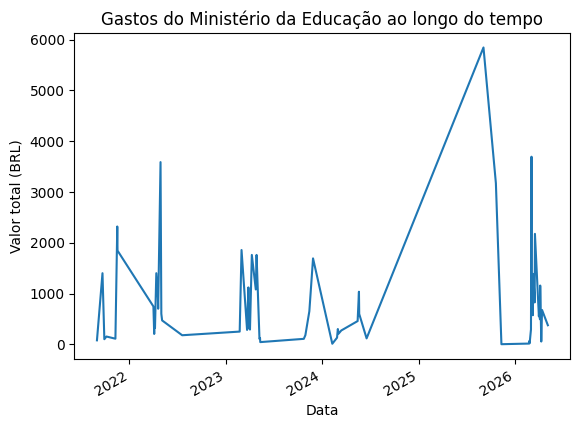

In [46]:
educacao.groupby('dataTransacao')['valorTransacao'].sum().plot(
    title='Gastos do Ministério da Educação ao longo do tempo',
    ylabel='Valor total (BRL)',
    xlabel='Data'
)


In [ ]:
#quero saber:
#quem dentro do ministerio da edu. fez mais transferencias?
#para quem?
#quem fez as transferência de maior valor?
#para quem?

In [47]:
#verificar se realmente só filtrou o M.da Educação #sim
educacao['orgao_max_nome'].unique()

<StringArray>
['Ministério da Educação']
Length: 1, dtype: str

In [100]:
cultura = entidade_gastos[entidade_gastos['orgao_max_nome'] == 'Ministério da Cultura'].sort_values('valorTransacao', ascending=False)
cultura['porcentagem'] = (cultura['valorTransacao'] / cultura['valorTransacao'].sum() * 100).round(1)
cultura

,orgao_max_nome,orgaoVinculado.nome,estabelecimento_nome,valorTransacao,porcentagem
3,Ministério da Cultura,Fundação Casa de Rui Barbosa,GIVANILTON SANTANA DA ROCHA,1700.00,21.5
2,Ministério da Cultura,Fundação Casa de Rui Barbosa,BOTTINO MATERIAIS DE CONSTRUCAO LTDA.,1697.30,21.4
12,Ministério da Cultura,Fundação Casa de Rui Barbosa,VITRINE DAS CORTINAS E REVESTIMENTOS LTDA,1505.00,19.0
5,Ministério da Cultura,Fundação Casa de Rui Barbosa,KEMOL SOLUCOES SUSTENTAVEIS LTDA,1100.00,13.9
8,Ministério da Cultura,Fundação Casa de Rui Barbosa,RJSS88 QUIMICAFINA LTDA,430.00,5.4
11,Ministério da Cultura,Fundação Casa de Rui Barbosa,TECIDOS E ARMARINHO 253 COMERCIO VAREJISTA DE ...,367.18,4.6
6,Ministério da Cultura,Fundação Casa de Rui Barbosa,PAGAR.ME S.A.,312.20,3.9
1,Ministério da Cultura,Fundação Casa de Rui Barbosa,AVICULTURA PROGRESSO - RIO - LTDA,287.00,3.6
9,Ministério da Cultura,Fundação Casa de Rui Barbosa,SEM INFORMACAO,200.00,2.5
7,Ministério da Cultura,Fundação Casa de Rui Barbosa,PAYPAL DO BRASIL INSTITUICAO DE PAGAMENTO LTDA,117.41,1.5


In [133]:
cultura = (
    df_final[df_final['orgao_max_nome'] == 'Ministério da Cultura']
    .sort_values('valorTransacao', ascending=False)
    .loc[:, ['orgao_max_nome', 'orgaoVinculado.nome', 'estabelecimento_nome', 'valorTransacao', 'dataTransacao']]
)

cultura['porcentagem'] = (cultura['valorTransacao'] / cultura['valorTransacao'].sum() * 100).round(1)

cultura.head()

,orgao_max_nome,orgaoVinculado.nome,estabelecimento_nome,valorTransacao,dataTransacao,porcentagem
74,Ministério da Cultura,Fundação Casa de Rui Barbosa,GIVANILTON SANTANA DA ROCHA,1700.0,2024-09-24,21.5
81,Ministério da Cultura,Fundação Casa de Rui Barbosa,BOTTINO MATERIAIS DE CONSTRUCAO LTDA.,1697.3,2024-08-14,21.4
120,Ministério da Cultura,Fundação Casa de Rui Barbosa,VITRINE DAS CORTINAS E REVESTIMENTOS LTDA,1505.0,2025-12-04,19.0
76,Ministério da Cultura,Fundação Casa de Rui Barbosa,KEMOL SOLUCOES SUSTENTAVEIS LTDA,1100.0,2025-02-20,13.9
80,Ministério da Cultura,Fundação Casa de Rui Barbosa,RJSS88 QUIMICAFINA LTDA,430.0,2024-09-04,5.4


<Axes: title={'center': 'Gastos do Ministério da Cultura ao longo do tempo'}, xlabel='Data', ylabel='Valor total (BRL)'>

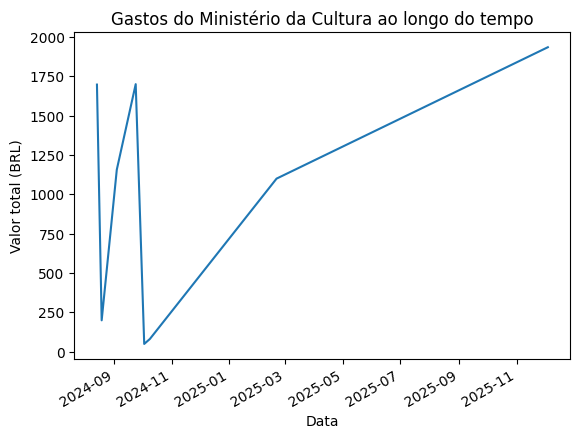

In [134]:
cultura.groupby('dataTransacao')['valorTransacao'].sum().plot(
    title='Gastos do Ministério da Cultura ao longo do tempo',
    ylabel='Valor total (BRL)',
    xlabel='Data'
)


In [101]:
defesa = entidade_gastos[entidade_gastos['orgao_max_nome'] == 'Ministério da Defesa'].sort_values('valorTransacao', ascending=False)
defesa['porcentagem'] = (defesa['valorTransacao'] / defesa['valorTransacao'].sum() * 100).round(1)
defesa

,orgao_max_nome,orgaoVinculado.nome,estabelecimento_nome,valorTransacao,porcentagem
22,Ministério da Defesa,Comando do Exército,RIGHI COMERCIO DE GENEROS ALIMENTICIOS LIMITADA,1700.58,35.5
13,Ministério da Defesa,Comando do Exército,ADOLAR DOS SANTOS BRUM,1110.00,23.2
23,Ministério da Defesa,Comando do Exército,TIFA IMPORTACAO E EXPORTACAO DE CONFECCOES LTDA,680.00,14.2
15,Ministério da Defesa,Comando do Exército,DENARDIN & DENARDIN COMERCIO DE COMBUSTIVEIS LTDA,489.20,10.2
18,Ministério da Defesa,Comando do Exército,LUIS AUGUSTO DE LIMA MACHADO,275.01,5.7
19,Ministério da Defesa,Comando do Exército,MARIA INES DOMINGOS FRANCA,183.61,3.8
17,Ministério da Defesa,Comando do Exército,GLOBAL INFORMATICA E SERVICOS LTDA,180.00,3.8
20,Ministério da Defesa,Comando do Exército,PACRIVIDROS LTDA,142.00,3.0
21,Ministério da Defesa,Comando do Exército,R & F COMERCIO DE EQUIPAMENTOS DE INFORMATICA ...,22.00,0.5
14,Ministério da Defesa,Comando do Exército,ARMARINHO VANDERLEIA LTDA,6.00,0.1


In [15]:
trabalho = entidade_gastos[entidade_gastos['orgao_max_nome'] == 'Ministério do Trabalho e Emprego'].sort_values('valorTransacao', ascending=False)
trabalho['porcentagem'] = (trabalho['valorTransacao'] / trabalho['valorTransacao'].sum() * 100).round(1)
trabalho

NameError: name 'entidade_gastos' is not defined

In [103]:
dhc = entidade_gastos[entidade_gastos['orgao_max_nome'] == 'Ministério dos Direitos Humanos e Cidadania'].sort_values('valorTransacao', ascending=False)
dhc

,orgao_max_nome,orgaoVinculado.nome,estabelecimento_nome,valorTransacao
95,Ministério dos Direitos Humanos e Cidadania,Ministério dos Direitos Humanos e Cidadania - ...,GOL LINHAS AEREAS S.A.,709.28


In [73]:
df_final.columns

Index(['id', 'dataTransacao', 'valorTransacao', 'unidade_gestora_nome',
       'orgaoVinculado.cnpj', 'orgaoVinculado.nome', 'orgaoMaximo.codigo',
       'orgao_max_nome', 'estabelecimento_id', 'estabelecimento_cpfFormatado',
       'estabelecimento_cnpjFormatado',
       'estabelecimento_numeroInscricaoSocial', 'estabelecimento_nome',
       'estabelecimento_razaoSocialReceita', 'estabelecimento_tipo'],
      dtype='str')

In [ ]:
#análise dos gastos por tempo
#quem gastou com mais frequencia?
#quem gastou em maior volume de dinheiro?

In [50]:
df_final.shape

(138, 15)

<Axes: xlabel='dataTransacao', ylabel='valorTransacao'>

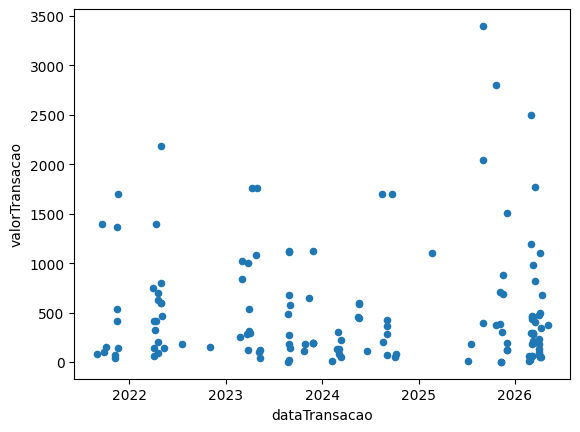

In [51]:
df_final.plot(x='dataTransacao', y='valorTransacao', kind='scatter')

In [57]:
df_final.columns

Index(['id', 'dataTransacao', 'valorTransacao', 'unidade_gestora_nome',
       'orgaoVinculado.cnpj', 'orgaoVinculado.nome', 'orgaoMaximo.codigo',
       'orgao_max_nome', 'estabelecimento_id', 'estabelecimento_cpfFormatado',
       'estabelecimento_cnpjFormatado',
       'estabelecimento_numeroInscricaoSocial', 'estabelecimento_nome',
       'estabelecimento_razaoSocialReceita', 'estabelecimento_tipo'],
      dtype='str')

In [ ]:
#quero exportar dados da data, valor e ministério
#quero passar os nomes dos ministérios para o inglês

In [24]:
df_final['orgao_max_nome'].unique()

<StringArray>
[                     'Ministério da Educação',
 'Ministério dos Direitos Humanos e Cidadania',
                        'Ministério da Defesa',
                       'Ministério da Cultura',
            'Ministério do Trabalho e Emprego']
Length: 5, dtype: str

In [23]:
traducao_orgaos = {
    'Ministério da Educação': 'Ministry of Education',
    'Ministério dos Direitos Humanos e Cidadania': 'Ministry of Human Rights and Citizenship',
    'Ministério da Defesa': 'Ministry of Defense',
    'Ministério da Cultura': 'Ministry of Culture',
    'Ministério do Trabalho e Emprego': 'Ministry of Labor and Employment',
}

df_final['orgao_max_nome_en'] = df_final['orgao_max_nome'].map(traducao_orgaos)

# confere se ficou algum não traduzido (NaN)
print(df_final['orgao_max_nome_en'].isna().sum())

df_final[['dataTransacao', 'valorTransacao', 'orgao_max_nome_en']] \
    .sort_values('dataTransacao') \
    .to_csv('transacoes_completas.csv', index=False, encoding='utf-8-sig')

0


In [60]:
#quero fazer um gráfico que mostra todas as transações nesse tipo de cartão por tempo
#para fazer gráfico fora, basta exportar as colunas. 
df_final[['dataTransacao', 'valorTransacao', 'orgao_max_nome']].sort_values('dataTransacao').to_csv('transacoes_completas_data_orgaos.csv', index=False)

In [28]:
#quantas transações cada órgão vez em todo o período? 
transacoes_qnt_orgao = df_final['orgao_max_nome_en'].value_counts().reset_index()
transacoes_qnt_orgao.columns = ['orgao', 'quantidade_transacoes']
transacoes_qnt_orgao

,orgao,quantidade_transacoes
0,Ministry of Education,103
1,Ministry of Culture,14
2,Ministry of Defense,13
3,Ministry of Labor and Employment,5
4,Ministry of Human Rights and Citizenship,3


In [29]:
#quero saber a porcentagem
#cria uma coluna para isso
trans_totais = transacoes_qnt_orgao['quantidade_transacoes'].sum()
transacoes_qnt_orgao['percentage'] = (transacoes_qnt_orgao['quantidade_transacoes']/trans_totais *100).round(1)
transacoes_qnt_orgao

,orgao,quantidade_transacoes,percentage
0,Ministry of Education,103,74.6
1,Ministry of Culture,14,10.1
2,Ministry of Defense,13,9.4
3,Ministry of Labor and Employment,5,3.6
4,Ministry of Human Rights and Citizenship,3,2.2


In [47]:
#pq tem 89? isso são que são ministérios? todos? #pq contou os dias de transação > e tiveram dias com mais de uma. 
gastos_por_tempo

,dataTransacao,valorTransacao
0,2021-08-31,77.60
1,2021-09-21,1400.00
2,2021-09-28,99.75
3,2021-10-06,152.80
4,2021-11-09,109.80
...,...,...
84,2026-04-07,1156.58
85,2026-04-10,339.59
86,2026-04-11,54.35
87,2026-04-14,676.00


In [124]:
gastos_por_tempo.to_csv('gastos_por_tempo.csv')

In [115]:
df_final.head()

,id,dataTransacao,valorTransacao,unidade_gestora_nome,orgaoVinculado.cnpj,orgaoVinculado.nome,orgaoMaximo.codigo,orgao_max_nome,estabelecimento_id,estabelecimento_cpfFormatado,estabelecimento_cnpjFormatado,estabelecimento_numeroInscricaoSocial,estabelecimento_nome,estabelecimento_razaoSocialReceita,estabelecimento_tipo
0,488182911,2022-04-02,745.00,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,8119578,,07.231.952/0001-65,,AGUAS CLARAS PRODUTOS E EQUIPAMENTOS PARA LAZE...,AGUAS CLARAS PRODUTOS E EQUIPAMENTOS PARA LAZE...,Entidades Empresariais Privadas
1,491826110,2022-04-06,420.00,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,-1,,,,SEM INFORMACAO,SEM INFORMACAO,Sem Informação
2,495555859,2022-04-05,145.75,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,6819806,,12.114.724/0001-45,,A J BARBOSA LTDA,A J BARBOSA LTDA,Entidades Empresariais Privadas
3,495555923,2022-04-05,57.63,IFMA/CAMPUS BURITICUPU,10735145000194,"Instituto Federal de Educação, Ciência e Tecno...",26000,Ministério da Educação,9419797,,03.867.404/0001-75,,ORIZA - MATERIAIS DE CONSTRUCOES LTDA,ORIZA - MATERIAIS DE CONSTRUCOES LTDA,Entidades Empresariais Privadas
4,500048984,2022-04-12,415.98,COORDENACAO-GERAL DE LOGISTICA - MDHC,27136980000100,Ministério dos Direitos Humanos e Cidadania - ...,81000,Ministério dos Direitos Humanos e Cidadania,6019904,,07.575.651/0001-59,,GOL LINHAS AEREAS S.A.,GOL LINHAS AEREAS S.A.,Entidades Empresariais Privadas


In [ ]:
#gastos de ministérios por tempo
#'orgao_max_nome'
#orgao_max_nome > 

In [ ]:
gastos_por_tempo = df_final.groupby(['orgao_max_nome'])['valorTransacao'].sum().reset_index()


In [29]:
#peguei os dados de julho de 2021 a dez de 2021 > para conseguir fazer a tabela dos últimos cinco anos. 
import pandas as pd

# ajuste o nome do arquivo pro que você baixou
df_2021_h2 = pd.read_csv('cartoes (1).csv', sep=';', encoding='utf-8')

df_2021_h2.head()
df_2021_h2.columns

Index(['success'], dtype='str')

,success


In [ ]:
#vou tentar manualmente baixar os dados de cada cartão e dos meses e
#somar 

In [ ]:
#CPGF 

In [3]:
cpgf_jul_21 = pd.read_csv('cvs.gov.2021/202107_CPGF.csv', encoding='latin-1', sep=';')
cpgf_jul_21.columns

Index(['CÓDIGO ÓRGÃO SUPERIOR', 'NOME ÓRGÃO SUPERIOR', 'CÓDIGO ÓRGÃO',
       'NOME ÓRGÃO', 'CÓDIGO UNIDADE GESTORA', 'NOME UNIDADE GESTORA',
       'ANO EXTRATO', 'MÊS EXTRATO', 'CPF PORTADOR', 'NOME PORTADOR',
       'CNPJ OU CPF FAVORECIDO', 'NOME FAVORECIDO', 'TRANSAÇÃO',
       'DATA TRANSAÇÃO', 'VALOR TRANSAÇÃO'],
      dtype='str')

In [4]:
cpgf_jul_21['VALOR TRANSAÇÃO']

0         250,00
1         200,00
2         800,00
3         800,00
4         150,00
          ...   
7475       40,41
7476    28128,00
7477     1496,18
7478      213,60
7479      177,87
Name: VALOR TRANSAÇÃO, Length: 7480, dtype: str

In [48]:
cpgf_jul_21['VALOR TRANSAÇÃO'] = pd.to_numeric(
    cpgf_jul_21['VALOR TRANSAÇÃO']
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False),
    errors='coerce'
)

In [49]:
total_cpgf_jul_21 = cpgf_jul_21['VALOR TRANSAÇÃO'].sum()
total_cpgf_jul_21

np.float64(5573489.720000001)

In [ ]:
#do cartão de compras centralizadas só tem alguns desses meses.

In [4]:
import pandas as pd
import glob

arquivos = glob.glob('cvs.gov.2021/2021*_CP*.csv')  # ajuste o caminho da pasta se necessário
print(arquivos)

# mapa pra normalizar nomes de tipo de cartão
normaliza_tipo = {
    'CPGF': 'CPGF',
    'CPDC': 'CPDC',
    'CPGFComprasCentralizadas': 'CPCC'
}

resultados = []

for caminho in arquivos:
    nome = caminho.replace('.csv', '')
    ano_mes, tipo_bruto = nome.split('_', 1)
    tipo = normaliza_tipo.get(tipo_bruto, tipo_bruto)  # se não achar no mapa, mantém como veio
    
    df = pd.read_csv(caminho, encoding='latin-1', sep=';')
    
    df['VALOR TRANSAÇÃO'] = pd.to_numeric(
        df['VALOR TRANSAÇÃO']
            .astype(str)
            .str.replace('.', '', regex=False)
            .str.replace(',', '.', regex=False),
        errors='coerce'
    )
    
    total = df['VALOR TRANSAÇÃO'].sum()
    
    resultados.append({
        'tipo_cartao': tipo,
        'ano_mes': ano_mes,
        'valor_total': total
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

['cvs.gov.2021\\202107_CPDC.csv', 'cvs.gov.2021\\202107_CPGF.csv', 'cvs.gov.2021\\202108_CPDC.csv', 'cvs.gov.2021\\202108_CPGF.csv', 'cvs.gov.2021\\202109_CPDC.csv', 'cvs.gov.2021\\202109_CPGF.csv', 'cvs.gov.2021\\202110_CPDC.csv', 'cvs.gov.2021\\202110_CPGF.csv', 'cvs.gov.2021\\202110_CPGFComprasCentralizadas.csv', 'cvs.gov.2021\\202111_CPDC.csv', 'cvs.gov.2021\\202111_CPGF.csv', 'cvs.gov.2021\\202111_CPGFComprasCentralizadas.csv', 'cvs.gov.2021\\202112_CPDC.csv', 'cvs.gov.2021\\202112_CPGF.csv', 'cvs.gov.2021\\202112_CPGFComprasCentralizadas.csv']


,tipo_cartao,ano_mes,valor_total
0,CPDC,cvs.gov.2021\202107,18730310.23
1,CPGF,cvs.gov.2021\202107,5573489.72
2,CPDC,cvs.gov.2021\202108,21868365.75
3,CPGF,cvs.gov.2021\202108,4486608.14
4,CPDC,cvs.gov.2021\202109,15674066.86
5,CPGF,cvs.gov.2021\202109,5478694.04
6,CPDC,cvs.gov.2021\202110,20240144.14
7,CPGF,cvs.gov.2021\202110,5619007.95
8,CPCC,cvs.gov.2021\202110,1477.60
9,CPDC,cvs.gov.2021\202111,15198435.52


In [ ]:
#total por semestre > julho a dez. de 2021.

In [5]:
totais_2021_h2 = df_resultados.groupby('tipo_cartao')['valor_total'].sum().reset_index()
totais_2021_h2

,tipo_cartao,valor_total
0,CPCC,6004.81
1,CPDC,98475231.84
2,CPGF,35882846.12


In [ ]:
#juntar no csv que eu peguei os totais dos últimos cinco anos > e montar gráfico mostrando como o uso desse cartão é limitado
#hipótese inicial

In [ ]:
#somando todos gastos > quanto por cento cada gastão gastou nos últimos 5 anos?

In [6]:
total_tds_cartos_5_anos = pd.read_csv('gastos_cartoes_2021_2026_corrigido - gastos_cartoes_2021_2026_corrigido.csv')
total_tds_cartos_5_anos

,tipo_cartao,ano,valor_total
0,CPCC,2021 (jul-dez),6.004810e+03
1,CPDC,2021 (jul-dez),9.847523e+07
2,CPGF,2021 (jul-dez),3.588285e+07
3,CPGF,2022,9.027110e+07
4,CPCC,2022,1.026016e+04
5,CPDC,2022,3.326312e+08
6,CPGF,2023,9.062865e+07
7,CPCC,2023,1.506379e+04
8,CPDC,2023,3.398848e+08
9,CPGF,2024,1.004766e+08


In [9]:
# Soma o valor total gasto por tipo de cartão (todos os anos juntos)
total_por_cartao = total_tds_cartos_5_anos.groupby('tipo_cartao')['valor_total'].sum()
total_por_cartao

tipo_cartao
CPCC    7.365208e+04
CPDC    1.827393e+09
CPGF    4.781498e+08
Name: valor_total, dtype: float64

In [12]:
porcentual_por_cartao = (total_por_cartao/total_por_cartao.sum()) *100
porcentual_por_cartao.round(3)

tipo_cartao
CPCC     0.003
CPDC    79.258
CPGF    20.738
Name: valor_total, dtype: float64